In [4]:
#Importing the Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt 


In [33]:
# Reading customer dataset
customers = pd.read_csv('customer_data.csv.zip', compression='zip')
customers.info()
customers.describe()
print(customers.head())

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     99457 non-null  str    
 1   gender          99457 non-null  str    
 2   age             99338 non-null  float64
 3   payment_method  99457 non-null  str    
dtypes: float64(1), str(3)
memory usage: 3.0 MB
  customer_id  gender   age payment_method
0     C241288  Female  28.0    Credit Card
1     C111565    Male  21.0     Debit Card
2     C266599    Male  20.0           Cash
3     C988172  Female  66.0    Credit Card
4     C189076  Female  53.0           Cash


In [34]:
# Checking Null values in customer data

print(customers.isnull().sum())

customer_id         0
gender              0
age               119
payment_method      0
dtype: int64


In [36]:
# Handling the null values in age column

customers['age'] = customers['age'].fillna(customers['age'].median())
print(customers.isnull().sum())

customer_id       0
gender            0
age               0
payment_method    0
dtype: int64


In [35]:
# Checking the duplicates in customer data


customers_duplicates = customers.duplicated().sum()
print(customers_duplicates)

0


In [9]:
# Sales dataset

sales = pd.read_csv('sales_data.csv.zip', compression='zip')
sales.info()
sales.describe()
print(sales.head())

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   invoice_no     99457 non-null  str    
 1   customer_id    99457 non-null  str    
 2   category       99457 non-null  str    
 3   quantity       99457 non-null  int64  
 4   price          99457 non-null  float64
 5   invoice_date   99457 non-null  str    
 6   shopping_mall  99457 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 5.3 MB
  invoice_no customer_id  category  quantity    price invoice_date  \
0    I138884     C241288  Clothing         5  1500.40   05-08-2022   
1    I317333     C111565     Shoes         3  1800.51   12-12-2021   
2    I127801     C266599  Clothing         1   300.08   09-11-2021   
3    I173702     C988172     Shoes         5  3000.85   16-05-2021   
4    I337046     C189076     Books         4    60.60   24-10-2021   

    shopping_mall  
0       

In [10]:
# Inspecting dataset

sales.info()
sales.describe()

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   invoice_no     99457 non-null  str    
 1   customer_id    99457 non-null  str    
 2   category       99457 non-null  str    
 3   quantity       99457 non-null  int64  
 4   price          99457 non-null  float64
 5   invoice_date   99457 non-null  str    
 6   shopping_mall  99457 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 5.3 MB


,quantity,price
count,99457.000000,99457.000000
mean,3.003429,689.256321
std,1.413025,941.184567
min,1.000000,5.230000
25%,2.000000,45.450000
50%,3.000000,203.300000
75%,4.000000,1200.320000
max,5.000000,5250.000000


In [11]:
# Checking null values

sales.isnull().sum()

invoice_no       0
customer_id      0
category         0
quantity         0
price            0
invoice_date     0
shopping_mall    0
dtype: int64

In [12]:
# Checking the duplicates in sales Data

sales_duplicates = sales.duplicated().sum()
print(sales_duplicates)

0


In [13]:
# Converting Invoice date Datatype from string to Date

sales['invoice_date'] = pd.to_datetime(sales['invoice_date'], format='%d-%m-%Y')

In [14]:
# Merging two dataset

customers_sales = customers.merge(sales, on = 'customer_id', how='inner')
customers_sales

,customer_id,gender,age,payment_method,invoice_no,category,quantity,price,invoice_date,shopping_mall
0,C241288,Female,28.0,Credit Card,I138884,Clothing,5,1500.40,2022-08-05,Kanyon
1,C111565,Male,21.0,Debit Card,I317333,Shoes,3,1800.51,2021-12-12,Forum Istanbul
2,C266599,Male,20.0,Cash,I127801,Clothing,1,300.08,2021-11-09,Metrocity
3,C988172,Female,66.0,Credit Card,I173702,Shoes,5,3000.85,2021-05-16,Metropol AVM
4,C189076,Female,53.0,Cash,I337046,Books,4,60.60,2021-10-24,Kanyon
...,...,...,...,...,...,...,...,...,...,...
99452,C441542,Female,45.0,Credit Card,I219422,Souvenir,5,58.65,2022-09-21,Kanyon
99453,C569580,Male,27.0,Cash,I325143,Food & Beverage,2,10.46,2021-09-22,Forum Istanbul
99454,C103292,Male,63.0,Debit Card,I824010,Food & Beverage,2,10.46,2021-03-28,Metrocity
99455,C800631,Male,56.0,Cash,I702964,Technology,4,4200.00,2021-03-16,Istinye Park


In [15]:
# ----Finding out the total Revenue
customers_sales['total_revenue'] = customers_sales['price'] * customers_sales['quantity']
print(f"Total Revenue: ${customers_sales['total_revenue'].sum():,.2f}")

Total Revenue: $251,505,794.25


In [16]:
# Create age groups
customers_sales['age group'] = pd.cut(customers_sales['age'], bins=[0, 30, 45, 120],labels=['Young (18-30)', 'Middle (31-45)', 'Senior (46+)'])
customers_sales['age group']

0         Young (18-30)
1         Young (18-30)
2         Young (18-30)
3          Senior (46+)
4          Senior (46+)
              ...      
99452    Middle (31-45)
99453     Young (18-30)
99454      Senior (46+)
99455      Senior (46+)
99456    Middle (31-45)
Name: age group, Length: 99457, dtype: category
Categories (3, str): ['Young (18-30)' < 'Middle (31-45)' < 'Senior (46+)']

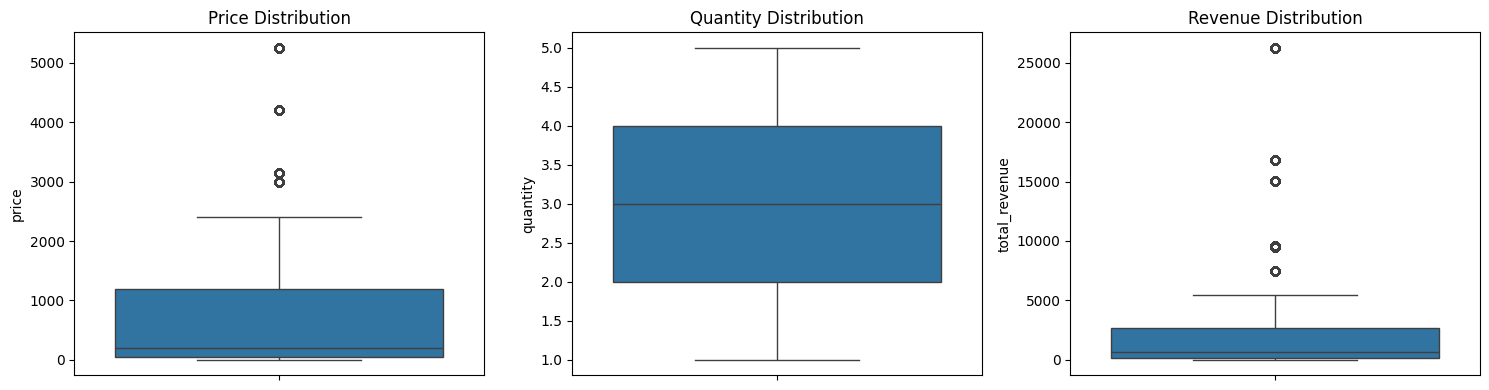

In [17]:
# Boxplot to check outliers in price, quantity and revenue
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=customers_sales['price'])
plt.title('Price Distribution')

plt.subplot(1, 3, 2)
sns.boxplot(y=customers_sales['quantity'])
plt.title('Quantity Distribution')

plt.subplot(1, 3, 3)
sns.boxplot(y=customers_sales['total_revenue'])
plt.title('Revenue Distribution')

plt.tight_layout()
plt.show()

In [18]:
# Boxplot
Q1_price = customers_sales['price'].quantile(0.25)
Q3_price = customers_sales['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
price_outliers = customers_sales[(customers_sales['price'] < Q1_price - 1.5*IQR_price) | (customers_sales['price'] > Q3_price + 1.5*IQR_price)]
print(f"Number of price outliers: {len(price_outliers)} ({len(price_outliers)/len(customers_sales)*100:.2f}%)")

Number of price outliers: 5024 (5.05%)


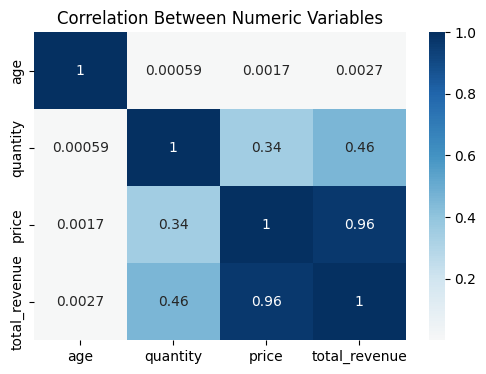

In [19]:
# Only numeric columns for correlation
numeric_data = customers_sales[['age', 'quantity', 'price', 'total_revenue']]

# Calculate correlation
correlation = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='RdBu', center=0)
plt.title('Correlation Between Numeric Variables')
plt.show()

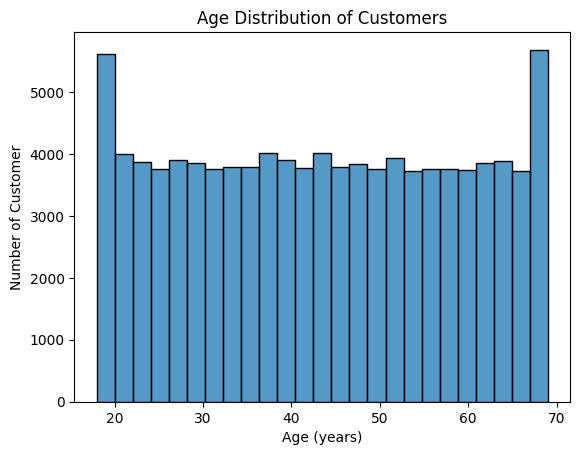

In [20]:
# Age distribution ---->visuals

sns.histplot(customers_sales['age'], bins=25)
plt.xlabel('Age (years)')
plt.ylabel('Number of Customer')
plt.title('Age Distribution of Customers')
plt.show()

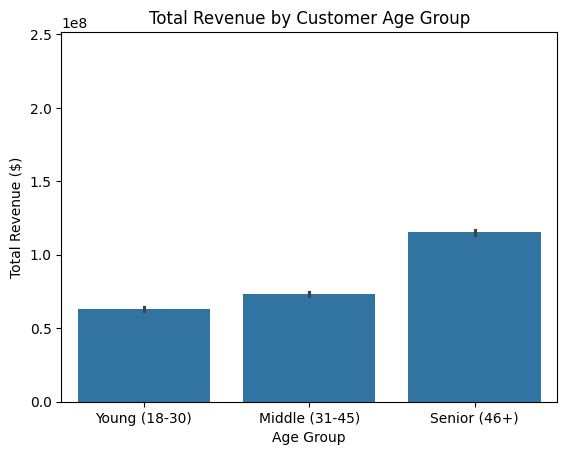

In [21]:
# Age distribution ---> total spent by each group

sns.barplot(customers_sales, x = 'age group', y = 'total_revenue', estimator=sum)
plt.ylim(0, customers_sales['total_revenue'].sum())
plt.title('Total Revenue by Customer Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue ($)')
plt.show()

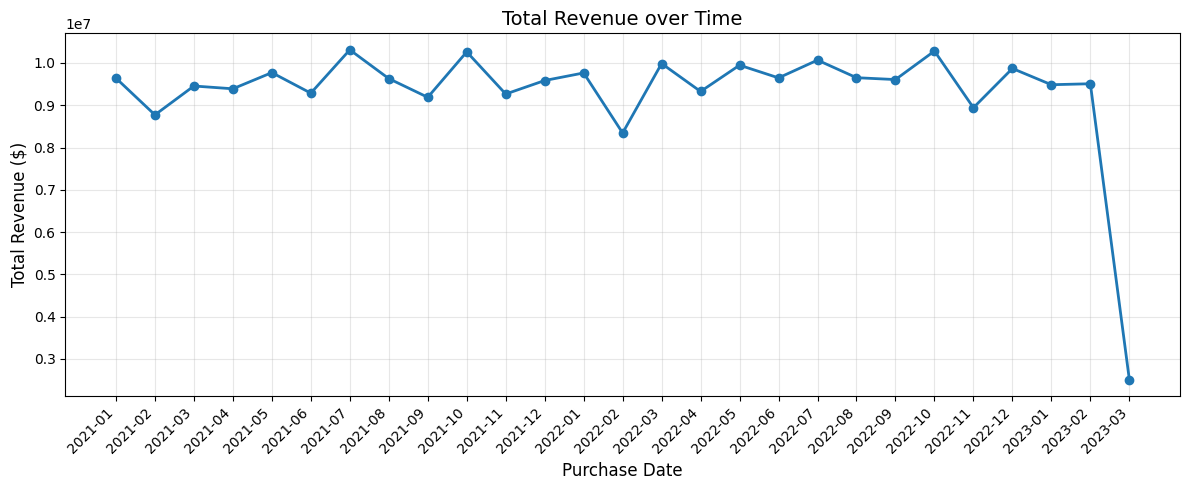

In [22]:
# Trend Analysis Visual----> invoice date by sales

# Replace your existing plot code with this
month = customers_sales['invoice_date'].dt.to_period('M')
monthly_revenue = customers_sales.groupby(month)['total_revenue'].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker='o', linewidth=2)
plt.xlabel('Purchase Date', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.title('Total Revenue over Time', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Insight 1: Age Analysis - Max spent age group.

# Grouping the ages in three categories
customers_sales['age group'] = pd.cut(customers_sales['age'], bins=[0,30,45,120], labels=['young', 'middle', 'senior'])

# Performing groupby and aggration to get the total summation by age group
revenue_by_agegroup = customers_sales.groupby('age group')['total_revenue'].sum()

# getting the maximum revenue generated by age group
revenue_by_agegroup.idxmax()


'senior'

In [24]:
# Insight 2: maximum spent age group.

# getting the maximum revenue generated by age group
revenue_by_agegroup.idxmin()

'young'

In [25]:
# Insight 3: Gender who visited mostly

most_visited_gender = customers_sales['gender'].value_counts().idxmax()
most_visited_gender

'Female'

In [26]:
# Insight 4: Gender with high revenue and low
revenue_by_gender = customers_sales.groupby('gender')['total_revenue'].sum()
print("Gender with high revenue: "+revenue_by_gender.idxmax())
print("Gender with low revenue: "+revenue_by_gender.idxmin())


Gender with high revenue: Female
Gender with low revenue: Male


In [27]:
# Insight 5: Most preferred and least preffered payment method by customers
payment_counts = customers_sales['payment_method'].value_counts()
most_preferred = payment_counts.idxmax()
least_preferred = payment_counts.idxmin()
print(f"Most preferred payment method: {most_preferred} ({payment_counts[most_preferred]} transactions)")
print(f"Least preferred payment method: {least_preferred} ({payment_counts[least_preferred]} transactions)")

Most preferred payment method: Cash (44447 transactions)
Least preferred payment method: Debit Card (20079 transactions)


In [28]:
# Insight 6: Category which generated high and low revenue

category_revenue = customers_sales.groupby(customers_sales['category'])['total_revenue'].sum()
print("Category which generated high revenue " + category_revenue.idxmax())
print("Category which generated low revenue " + category_revenue.idxmin())



Category which generated high revenue Clothing
Category which generated low revenue Souvenir


In [29]:
# Insight 7: Branch with highest and lowest revenue

shopping_mall_revenue = customers_sales.groupby(customers_sales['shopping_mall'])['total_revenue'].sum()
print("High revenue mall " + shopping_mall_revenue.idxmax())


High revenue mall Mall of Istanbul


In [30]:
# Insight 8: Category that has sold high and low quantity

category_quantity = customers_sales.groupby(customers_sales['category'])['quantity'].sum()
print("highest sales volume " + category_quantity.idxmax())
print("low sales volume " +category_quantity.idxmin())


highest sales volume Clothing
low sales volume Souvenir


In [31]:
# insight 9: Most loyal customer

customer_purchase_count = customers_sales.groupby('customer_id')['invoice_no'].nunique()
print("Customer with highest purchase is ", customer_purchase_count.idxmax())

Customer with highest purchase is  C100004


In [32]:
# insight 10: Best month for sales

customers_sales['month'] = customers_sales['invoice_date'].dt.month
sales_month = customers_sales.groupby('month')['total_revenue'].sum()
print("Month with highest revenue:", sales_month.idxmax())
print("Month with lowest revenue:", sales_month.idxmin())

Month with highest revenue: 1
Month with lowest revenue: 11
